
Task 1:


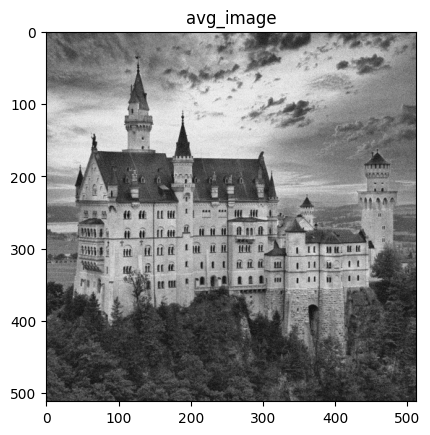

For theoretical, the average noise reduce for n images is 1/√n. 
Since we have 10 images, the theoretical reduce will be 1/√10, which is 0.316.

original image standard deviation: 20.27
average image standard deviation: 10.70
ratio(ori_std/avg_std): 0.53



In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import time

#Task 1
#input all the images:
image_dir = 'COMP9517_25T2_Lab1_Images'
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])
images = []
for filename in image_files:
    img = cv2.imread(os.path.join(image_dir, filename))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)
image_stack = np.stack(images, axis=0)

#caculate the average image:
avg_image = np.mean(image_stack, axis=0).astype(np.uint8)

#show the avg_image
print('\nTask 1:')
plt.imshow(avg_image)
plt.title('avg_image')
plt.show()

#Theoretical reduce
print(f'For theoretical, the average noise reduce for n images is 1/√n. \nSince we have 10 images, the theoretical reduce will be 1/√10, which is {(1/math.sqrt(10)):.3f}.\n')

#compair the standard deviation
ori_region = images[0][100:150, 220:270, :]
avg_region = avg_image[100:150, 220:270, :]
#change into gray
ori_region_gray = cv2.cvtColor(ori_region, cv2.COLOR_RGB2GRAY)
avg_region_gray = cv2.cvtColor(avg_region, cv2.COLOR_RGB2GRAY)
#calculate the standard deviation
ori_std = np.std(ori_region_gray)
avg_std = np.std(avg_region_gray)
ratio = avg_std/ori_std  

print(f"original image standard deviation: {ori_std:.2f}")
print(f"average image standard deviation: {avg_std:.2f}")
print(f"ratio(ori_std/avg_std): {ratio:.2f}\n")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-27.597656..23.503906].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-27.597656..23.503906].


[f * (h1 - h2)] took: 0.001 seconds
[f * h1 - f * h2] took: 0.003 seconds
[f * (h1 - h2)] is faster because there is only one convolution,
and the time cost of convolution is relatively expensive

pixel difference between two methods: 0.000
Are the results exactly the same? True.
Because by the definition of distributivity, each pixel goes through the same mathematical process, the results will be the same.


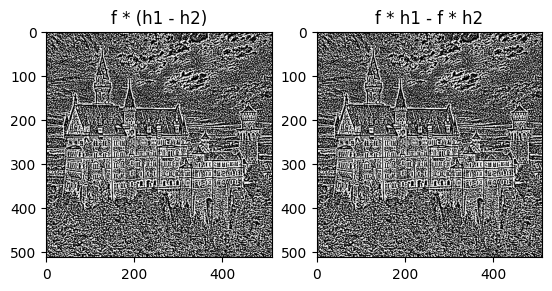

In [37]:
# Task 2

#change the avg_image to float32, or the negative data will be cut off
avg_img = avg_image.astype(np.float32)

# Set the Gaussian filters
h1 = (1/16) * np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 2, 1, 0],
    [0, 2, 4, 2, 0],
    [0, 1, 2, 1, 0],
    [0, 0, 0, 0, 0]
], dtype=np.float32)
h2 = (1/256) * np.array([
    [1,  4,  6,  4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1,  4,  6,  4, 1]
], dtype=np.float32)

# record time1 for f * (h1 - h2)
start1 = time.time()
DoG_kernel = h1 - h2
dog1 = cv2.filter2D(avg_img, -1, DoG_kernel)
end1 = time.time()
time1 = end1 - start1

# record time2 for f * h1 - f * h2
start2 = time.time()
blur1 = cv2.filter2D(avg_img, -1, h1)
blur2 = cv2.filter2D(avg_img, -1, h2)
dog2 = blur1 - blur2
end2 = time.time()
time2 = end2 - start2

#show the images

plt.subplot(1, 2, 1)
plt.title('f * (h1 - h2)')
plt.imshow(dog1, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('f * h1 - f * h2')
plt.imshow(dog2, cmap='gray')

#compare the time and image
print(f"[f * (h1 - h2)] took: {time1:.3f} seconds")
print(f"[f * h1 - f * h2] took: {time2:.3f} seconds")
print('[f * (h1 - h2)] is faster because there is only one convolution,\nand the time cost of convolution is relatively expensive\n')
difference = np.abs(dog1 - dog2)
max_diff = np.max(difference)
print(f"pixel difference between two methods: {max_diff:.3f}")
print(f"Are the results exactly the same? {np.allclose(dog1, dog2)}.\nBecause by the definition of distributivity, each pixel goes through the same mathematical process, the results will be the same.", )

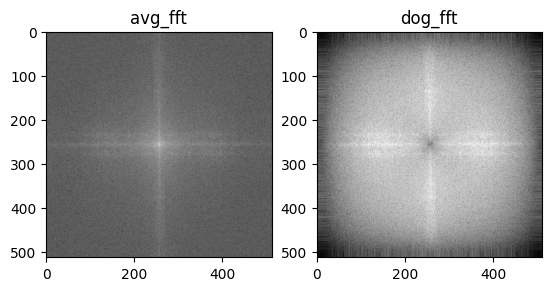

For avg_fft:
The image comes from the average operation, the bright center represents the low frequencies,
which correspond to slowly varying intensities across pixels result from noise reduction.
For dog_fft:
The center of the image represent low frequencies is darker, while the outer regions represent to high frequencies are brighter.
This indicates that the DoG filter acts as a high-pass filter


In [48]:
# Task 3
# define fft function
def change_fft(image):
    fft = np.fft.fft2(image)
    fft_shifted = np.fft.fftshift(fft)
    positive = np.abs(fft_shifted)
    result = np.log1p(positive)
    return result

#change the image into gray, or it will turn green(why?)
avg_img_gray = cv2.cvtColor(avg_img, cv2.COLOR_BGR2GRAY)
dog_img_gray = cv2.cvtColor(dog1, cv2.COLOR_BGR2GRAY)

#change into fft
avg_fft = change_fft(avg_img_gray)
dog_fft = change_fft(dog_img_gray)

#show the images
plt.subplot(1, 2, 1)
plt.imshow(avg_fft, cmap='gray')
plt.title('avg_fft')

plt.subplot(1, 2, 2)
plt.imshow(dog_fft, cmap='gray')
plt.title('dog_fft')

plt.show()

#The reason of difference
print('For avg_fft:\nThe image comes from the average operation, the bright center represents the low frequencies,\nwhich correspond to slowly varying intensities across pixels result from noise reduction.')
print('For dog_fft:\nThe center of the image represent low frequencies is darker, while the outer regions represent to high frequencies are brighter.\nThis indicates that the DoG filter acts as a high-pass filter')